# YOLOv5 Overfit Sanity Check (Tiny Subset)

Use this notebook to verify the model and training loop can memorize a very small dataset.

Expected behavior for a healthy setup:
- training loss drops strongly
- train-set mAP (reported as `val/map` here) rises toward 1.0

This is a debugging step before full-scale training.

In [ ]:
# If needed, uncomment and run in the active kernel.
# %pip install -q lightning torchmetrics ultralytics

In [1]:
from __future__ import annotations

import os
import random
import sys
import subprocess
from dataclasses import dataclass
from pathlib import Path
from typing import Any

import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

import lightning as L
from lightning.pytorch.callbacks import ModelCheckpoint

from torchmetrics.detection.mean_ap import MeanAveragePrecision

# Ensure project imports work from notebook location.
PROJECT_ROOT = Path('/work')
SCRIPTS_ROOT = PROJECT_ROOT / 'scripts'
for p in (PROJECT_ROOT, SCRIPTS_ROOT):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

import config
from detection_pipeline import (
    DetectionDownloadConfig,
    ToothDetectionDataset,
    build_detection_records,
    load_or_download_detection_dataset,
    split_grouped_records,
)

# Clone YOLOv5 if missing and put it first in import order for yolo-specific utils.
YOLOV5_DIR = PROJECT_ROOT / 'external' / 'yolov5'
YOLOV5_DIR.parent.mkdir(parents=True, exist_ok=True)
if not YOLOV5_DIR.exists():
    subprocess.run(
        ['git', 'clone', '--depth', '1', 'https://github.com/ultralytics/yolov5.git', str(YOLOV5_DIR)],
        check=True,
    )
if str(YOLOV5_DIR) not in sys.path:
    sys.path.insert(0, str(YOLOV5_DIR))

from models.yolo import Model
from utils.loss import ComputeLoss
from utils.general import intersect_dicts, non_max_suppression

print('Using project root:', PROJECT_ROOT)
print('Using YOLOv5 code from:', YOLOV5_DIR)

Using project root: /work
Using YOLOv5 code from: /work/external/yolov5


In [2]:
def seed_everything(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


@dataclass
class OverfitConfig:
    image_size: int = 640
    batch_size: int = 4
    num_workers: int = 0
    max_epochs: int = 80
    lr: float = 0.00045636389024364654
    weight_decay: float = 0.000005312109908408371
    adamw_beta1: float = 0.9
    adamw_beta2: float = 0.999
    conf_threshold: float = 0.001
    iou_threshold: float = 0.6
    pretrained_weights: str = 'yolov5s.pt'
    force_download: bool = False
    tiny_subset_size: int = 16
    seed: int = 42
    wandb_project: str = 'tooth-detection-overfit-check'
    wandb_run_name: str = 'yolov5-overfit-tiny-subset'


cfg = OverfitConfig()
seed_everything(cfg.seed)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)
print('Subset size:', cfg.tiny_subset_size)

Device: cuda
Subset size: 16


In [3]:
class YoloTargetAdapterDataset(Dataset):
    def __init__(self, base_dataset: Dataset):
        self.base_dataset = base_dataset

    def __len__(self) -> int:
        return len(self.base_dataset)

    def __getitem__(self, index: int):
        image, target = self.base_dataset[index]
        return image, target


def yolo_collate_fn(batch: list[tuple[torch.Tensor, dict[str, Any]]]):
    images = []
    yolo_targets = []
    metric_targets = []

    for i, (img, tgt) in enumerate(batch):
        images.append(img.float())

        boxes_xyxy = tgt['boxes'].float()
        labels_one_based = tgt['labels'].long()

        metric_targets.append({
            'boxes': boxes_xyxy,
            'labels': (labels_one_based - 1).clamp_min(0),
        })

        if boxes_xyxy.numel() == 0:
            continue

        _, h, w = img.shape
        x1, y1, x2, y2 = boxes_xyxy[:, 0], boxes_xyxy[:, 1], boxes_xyxy[:, 2], boxes_xyxy[:, 3]

        cx = ((x1 + x2) * 0.5) / w
        cy = ((y1 + y2) * 0.5) / h
        bw = (x2 - x1) / w
        bh = (y2 - y1) / h

        cls = (labels_one_based - 1).float().clamp_min(0)
        batch_idx = torch.full((boxes_xyxy.shape[0],), float(i), dtype=torch.float32)

        packed = torch.stack([batch_idx, cls, cx, cy, bw, bh], dim=1)
        yolo_targets.append(packed)

    images = torch.stack(images, dim=0)
    if yolo_targets:
        yolo_targets = torch.cat(yolo_targets, dim=0)
    else:
        yolo_targets = torch.zeros((0, 6), dtype=torch.float32)

    return images, yolo_targets, metric_targets


class OverfitDataModule(L.LightningDataModule):
    def __init__(self, cfg: OverfitConfig):
        super().__init__()
        self.cfg = cfg
        self.train_ds = None

    def setup(self, stage: str | None = None):
        _, coco_data, image_dirs = load_or_download_detection_dataset(
            DetectionDownloadConfig(api_key=os.getenv('ROBOFLOW_API_KEY')),
            force_download=self.cfg.force_download,
        )
        records, _ = build_detection_records(coco_data, image_dirs)

        # Support both record formats: with explicit subset tags and grouped split.
        train_rec = [r for r in records if r.get('subset') == 'train']
        if not train_rec:
            train_ratio = getattr(config, 'TRAIN_RATIO', 0.7)
            val_ratio = getattr(config, 'VAL_RATIO', 0.15)
            test_ratio = getattr(config, 'TEST_RATIO', 0.15)
            train_rec, _, _ = split_grouped_records(
                records,
                train_size=train_ratio,
                val_size=val_ratio,
                test_size=test_ratio,
                random_state=self.cfg.seed,
            )

        if len(train_rec) < self.cfg.tiny_subset_size:
            raise RuntimeError(
                f'Not enough train samples after split: {len(train_rec)} < {self.cfg.tiny_subset_size}. '
                'Lower cfg.tiny_subset_size or verify dataset download/split configuration.'
            )

        rng = np.random.default_rng(self.cfg.seed)
        chosen_idx = rng.choice(len(train_rec), size=self.cfg.tiny_subset_size, replace=False)
        tiny_train = [train_rec[int(i)] for i in chosen_idx]

        base_train = ToothDetectionDataset(
            tiny_train, image_size=self.cfg.image_size, output_channels=3
        )
        self.train_ds = YoloTargetAdapterDataset(base_train)

        print(f'Using fixed tiny subset of {len(self.train_ds)} samples for both train and val.')

    def _loader_kwargs(self) -> dict[str, Any]:
        num_workers = int(self.cfg.num_workers)
        kwargs: dict[str, Any] = {
            'num_workers': num_workers,
            'pin_memory': torch.cuda.is_available(),
            'collate_fn': yolo_collate_fn,
        }
        if num_workers > 0:
            kwargs['persistent_workers'] = True
            kwargs['prefetch_factor'] = 2
        return kwargs

    def train_dataloader(self):
        return DataLoader(
            self.train_ds,
            batch_size=self.cfg.batch_size,
            shuffle=True,
            drop_last=False,
            **self._loader_kwargs(),
        )

    def val_dataloader(self):
        return DataLoader(
            self.train_ds,
            batch_size=self.cfg.batch_size,
            shuffle=False,
            drop_last=False,
            **self._loader_kwargs(),
        )

In [4]:
class LitYOLOv5(L.LightningModule):
    def __init__(self, cfg: OverfitConfig, num_classes: int = 32):
        super().__init__()
        self.save_hyperparameters(ignore=['cfg'])

        self.cfg = cfg
        self.num_classes = num_classes
        self.compute_loss = None

        ckpt_path = Path(cfg.pretrained_weights)
        ckpt = torch.load(ckpt_path, map_location='cpu')

        yolo_cfg = ckpt['model'].yaml
        self.model = Model(yolo_cfg, ch=3, nc=num_classes).float()

        pretrained_state = ckpt['model'].float().state_dict()
        compatible_state = intersect_dicts(
            pretrained_state,
            self.model.state_dict(),
            exclude=['anchor'],
        )
        self.model.load_state_dict(compatible_state, strict=False)

        self.model.hyp = {
            'box': 0.05,
            'cls': 0.3,
            'obj': 0.7,
            'cls_pw': 1.0,
            'obj_pw': 1.0,
            'fl_gamma': 0.0,
            'label_smoothing': 0.0,
            'anchor_t': 4.0,
        }

        self.map_metric = MeanAveragePrecision(box_format='xyxy', class_metrics=False)

    def on_train_start(self):
        self.model.to(self.device)
        self.compute_loss = ComputeLoss(self.model)
        self._fix_compute_loss_device()

    def _fix_compute_loss_device(self):
        if self.compute_loss is None:
            return

        self.compute_loss.device = self.device

        for name, value in vars(self.compute_loss).items():
            if torch.is_tensor(value):
                setattr(self.compute_loss, name, value.to(self.device))
            elif isinstance(value, list):
                setattr(
                    self.compute_loss,
                    name,
                    [item.to(self.device) if torch.is_tensor(item) else item for item in value],
                )
            elif isinstance(value, tuple):
                setattr(
                    self.compute_loss,
                    name,
                    tuple(item.to(self.device) if torch.is_tensor(item) else item for item in value),
                )

        if hasattr(self.compute_loss, 'anchors'):
            self.compute_loss.anchors = self.compute_loss.anchors.to(self.device)

    def forward(self, x: torch.Tensor):
        return self.model(x)

    def training_step(self, batch, batch_idx: int):
        images, yolo_targets, _ = batch

        yolo_targets = yolo_targets.to(images.device, non_blocking=True)

        if self.compute_loss is None:
            self.compute_loss = ComputeLoss(self.model)

        self._fix_compute_loss_device()

        preds = self.model(images)
        loss, loss_items = self.compute_loss(preds, yolo_targets)

        self.log('train/loss', loss, prog_bar=True, on_step=True, on_epoch=True, batch_size=images.size(0))
        self.log('train/loss_box', loss_items[0], on_step=True, on_epoch=True, batch_size=images.size(0))
        self.log('train/loss_obj', loss_items[1], on_step=True, on_epoch=True, batch_size=images.size(0))
        self.log('train/loss_cls', loss_items[2], on_step=True, on_epoch=True, batch_size=images.size(0))

        return loss

    def validation_step(self, batch, batch_idx: int):
        images, _, metric_targets = batch

        raw_output = self.model(images)
        preds = raw_output[0] if isinstance(raw_output, (tuple, list)) else raw_output

        nms_preds = non_max_suppression(
            preds,
            conf_thres=self.cfg.conf_threshold,
            iou_thres=self.cfg.iou_threshold,
            multi_label=False,
            max_det=300,
        )

        metric_preds = []
        for det in nms_preds:
            if det is None or len(det) == 0:
                metric_preds.append({
                    'boxes': torch.zeros((0, 4), device=self.device),
                    'scores': torch.zeros((0,), device=self.device),
                    'labels': torch.zeros((0,), dtype=torch.long, device=self.device),
                })
                continue

            metric_preds.append({
                'boxes': det[:, :4],
                'scores': det[:, 4],
                'labels': det[:, 5].long(),
            })

        metric_targets = [
            {
                'boxes': target['boxes'].to(self.device),
                'labels': target['labels'].to(self.device),
            }
            for target in metric_targets
        ]

        self.map_metric.update(metric_preds, metric_targets)

    def on_validation_epoch_end(self):
        metrics = self.map_metric.compute()
        self.log('val/map', metrics['map'], prog_bar=True)
        self.log('val/map_50', metrics['map_50'], prog_bar=True)
        self.log('val/map_75', metrics['map_75'])
        self.map_metric.reset()

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(
            self.model.parameters(),
            lr=self.cfg.lr,
            weight_decay=self.cfg.weight_decay,
            betas=(self.cfg.adamw_beta1, self.cfg.adamw_beta2),
        )

        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=self.cfg.max_epochs,
        )

        return {
            'optimizer': optimizer,
            'lr_scheduler': {
                'scheduler': scheduler,
                'interval': 'epoch',
                'frequency': 1,
            },
        }

In [5]:
# Download pretrained YOLOv5 weights if missing.
weights_path = Path(cfg.pretrained_weights)
if not weights_path.exists():
    import urllib.request

    url = 'https://github.com/ultralytics/yolov5/releases/download/v7.0/yolov5s.pt'
    urllib.request.urlretrieve(url, str(weights_path))

print('Using weights:', weights_path.resolve())

Using weights: /work/scripts/detection_pipeline/training/yolov5s.pt


In [6]:
from lightning.pytorch.loggers import WandbLogger

try:
    from dotenv import load_dotenv
except ImportError:
    load_dotenv = None

env_path = PROJECT_ROOT / '.env'
if load_dotenv is not None and env_path.exists():
    load_dotenv(env_path, override=True)

wandb_key = (os.getenv('WANDB_API_KEY') or '').strip().strip('"').strip("'")
use_wandb = bool(wandb_key)
wandb_logger = False

if use_wandb:
    import wandb

    os.environ['WANDB_API_KEY'] = wandb_key
    wandb.login(key=wandb_key, relogin=True)
    wandb_logger = WandbLogger(
        project=cfg.wandb_project,
        name=cfg.wandb_run_name,
        log_model=True,
    )
    print('W&B enabled:', cfg.wandb_project, cfg.wandb_run_name)
else:
    print('WANDB_API_KEY not found. Running without W&B logging.')

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: eznagyonkellettmz (eznagyonkellettmz-budapesti-m-szaki-s-gazdas-gtudom-nyi-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


W&B enabled: tooth-detection-overfit-check yolov5-overfit-tiny-subset


Using fixed tiny subset of 16 samples for both train and val.


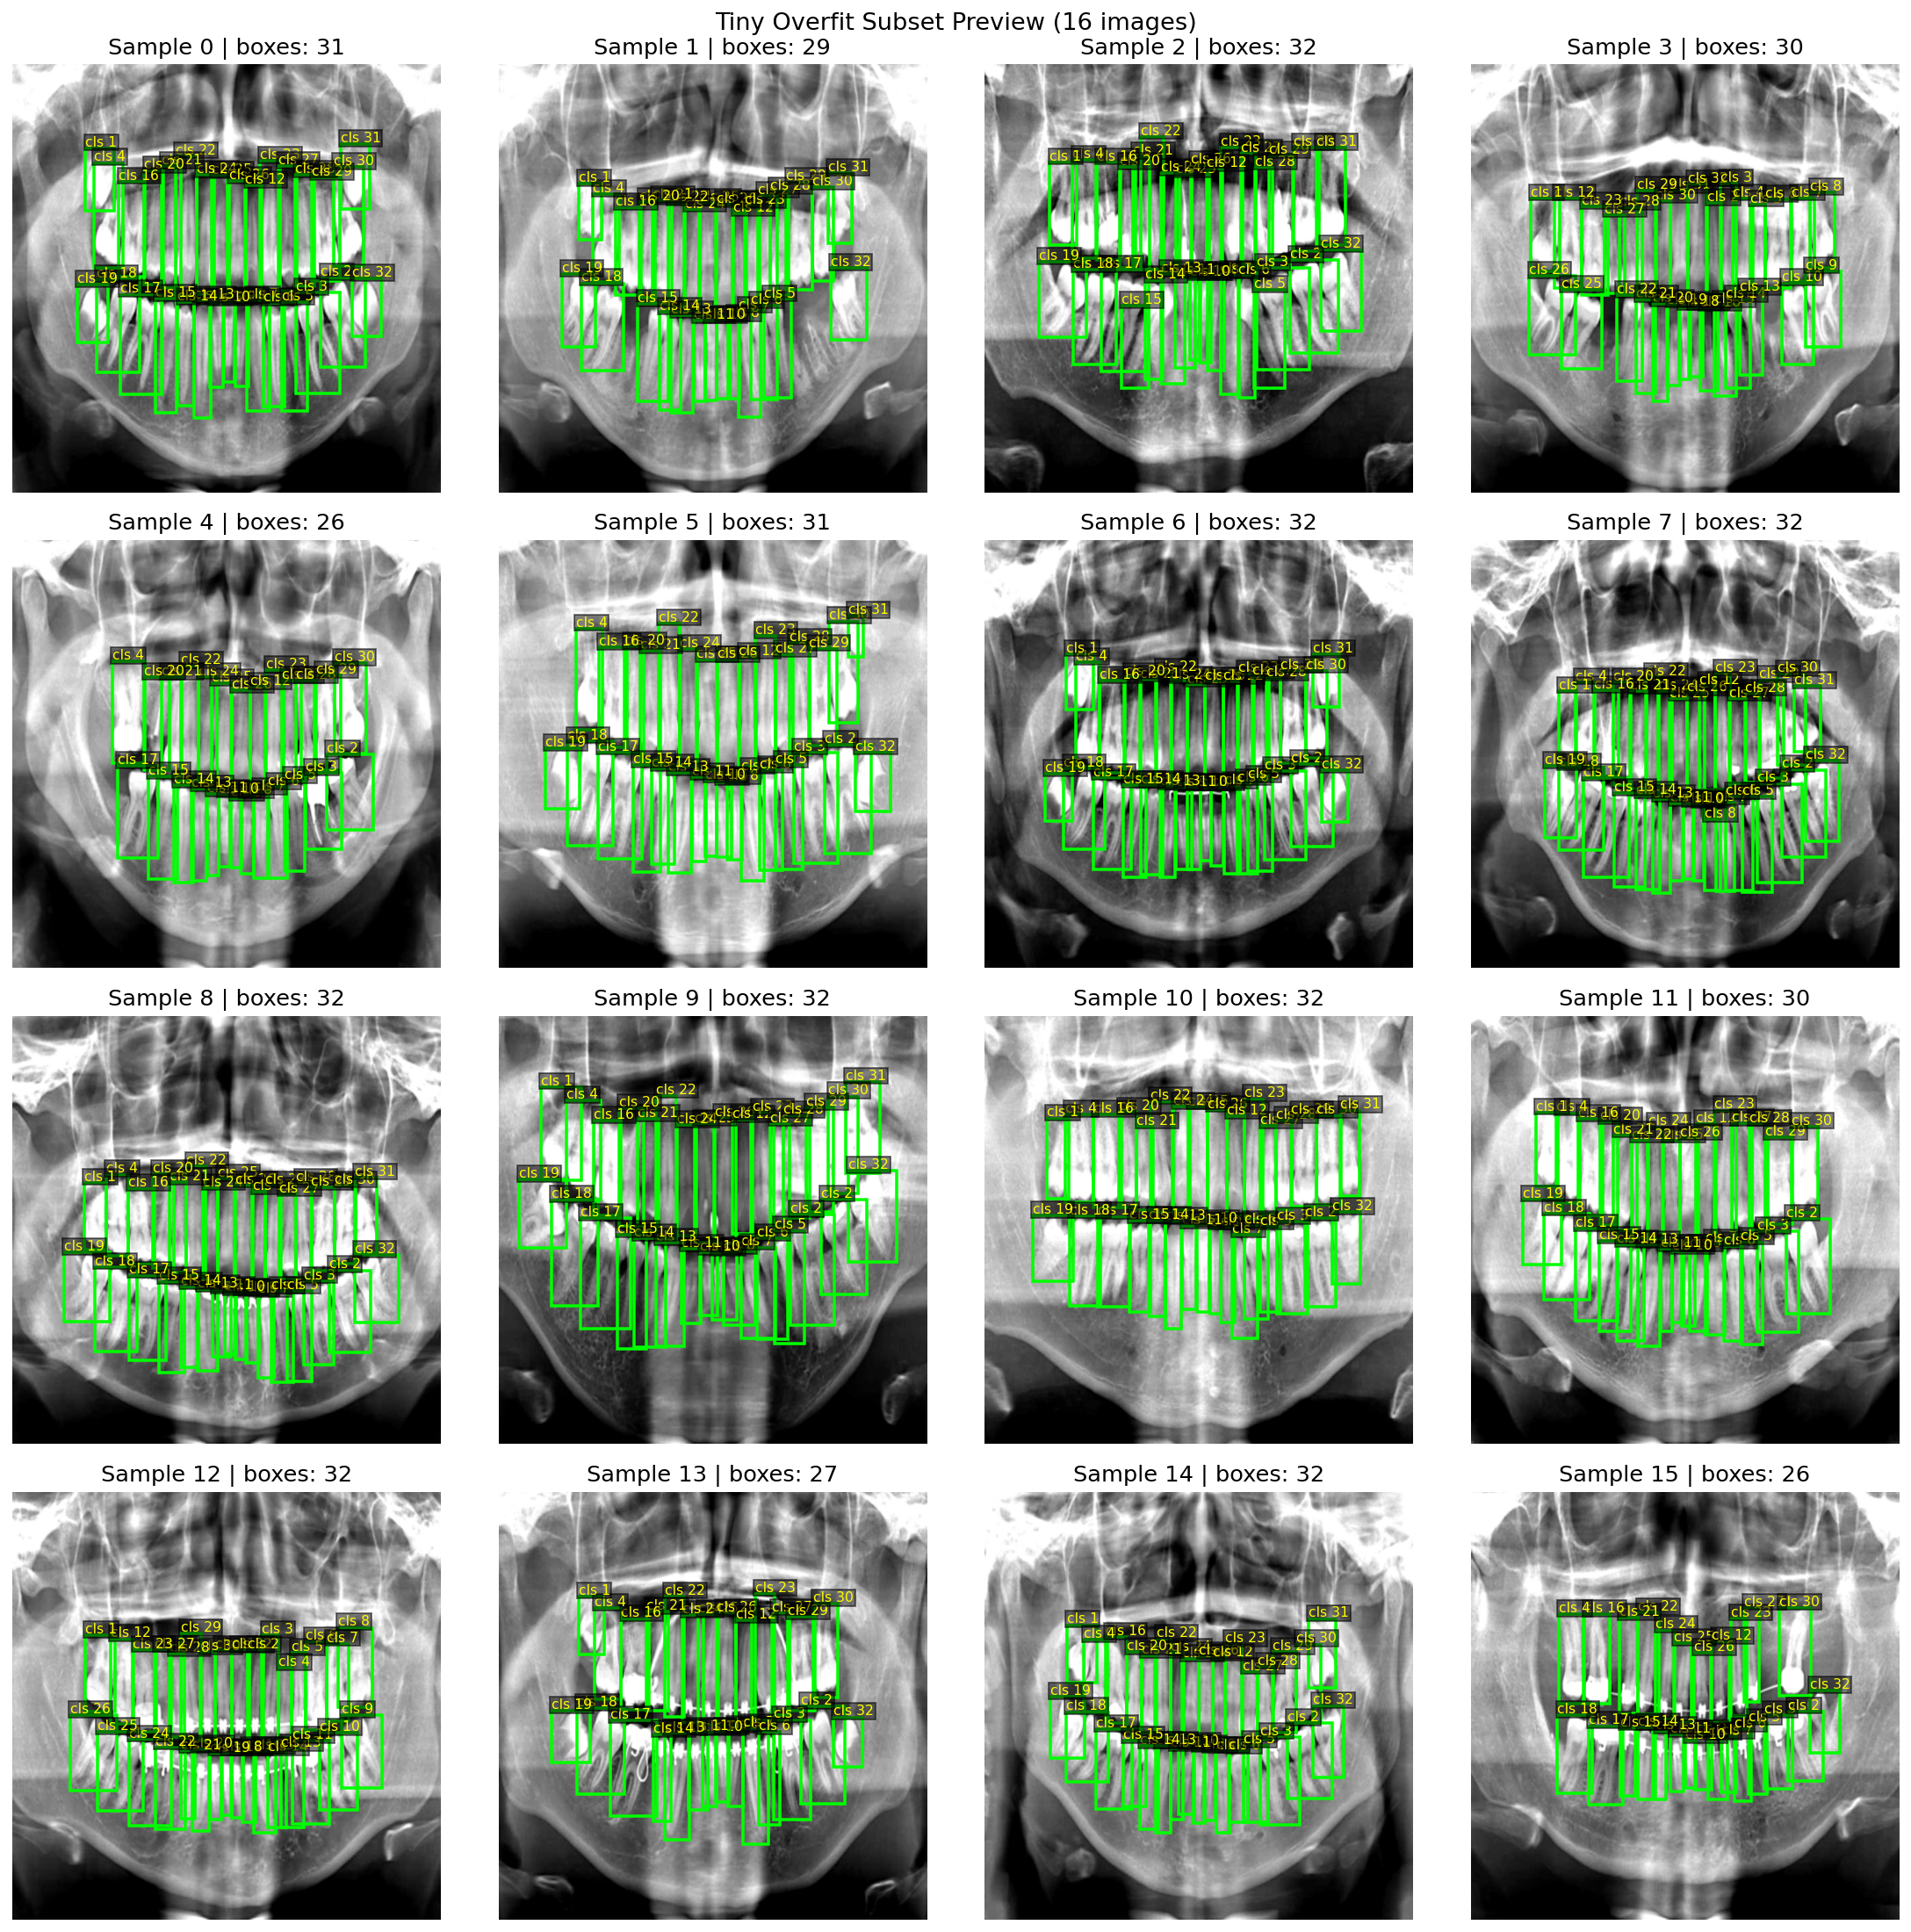

In [7]:
import math
from io import BytesIO

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from IPython.display import Image, display

datamodule = OverfitDataModule(cfg)
datamodule.setup('fit')

tiny_ds = datamodule.train_ds
num_to_show = min(16, len(tiny_ds))
cols = 4
rows = math.ceil(num_to_show / cols)

fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
axes = np.array(axes).reshape(rows, cols)

for idx in range(rows * cols):
    ax = axes[idx // cols, idx % cols]
    if idx >= num_to_show:
        ax.axis('off')
        continue

    image, target = tiny_ds[idx]

    if torch.is_tensor(image):
        img = image.detach().cpu().float()
        if img.ndim == 3 and img.shape[0] in (1, 3):
            img = img.permute(1, 2, 0)
        img = img.numpy()
    else:
        img = np.asarray(image, dtype=np.float32)

    if img.ndim == 3 and img.shape[-1] == 1:
        img = img[..., 0]

    min_v = float(np.min(img))
    max_v = float(np.max(img))
    if max_v > min_v:
        img = (img - min_v) / (max_v - min_v)
    else:
        img = np.zeros_like(img, dtype=np.float32)

    img = np.clip(img, 0.0, 1.0)

    if img.ndim == 2:
        ax.imshow(img, cmap='gray')
    else:
        ax.imshow(img)

    boxes = target['boxes'].detach().cpu().numpy()
    labels = target['labels'].detach().cpu().numpy()

    for box, label in zip(boxes, labels):
        x1, y1, x2, y2 = box.tolist()
        w = max(0.0, x2 - x1)
        h = max(0.0, y2 - y1)
        ax.add_patch(Rectangle((x1, y1), w, h, fill=False, linewidth=1.8, edgecolor='lime'))
        ax.text(
            x1,
            max(y1 - 3.0, 0.0),
            f'cls {int(label)}',
            color='yellow',
            fontsize=8,
            bbox={'facecolor': 'black', 'alpha': 0.5, 'pad': 1},
        )

    ax.set_title(f'Sample {idx} | boxes: {len(boxes)}')
    ax.axis('off')

fig.suptitle(f'Tiny Overfit Subset Preview ({num_to_show} images)', fontsize=14)
fig.tight_layout()

buffer = BytesIO()
fig.savefig(buffer, format='png', bbox_inches='tight', dpi=140)
buffer.seek(0)
display(Image(data=buffer.getvalue()))
plt.close(fig)

In [8]:
if 'datamodule' not in globals():
    datamodule = OverfitDataModule(cfg)
if getattr(datamodule, 'train_ds', None) is None:
    datamodule.setup('fit')

model = LitYOLOv5(cfg=cfg, num_classes=32)

checkpoint_cb = ModelCheckpoint(
    dirpath=str(PROJECT_ROOT / 'output' / 'checkpoints'),
    filename='yolov5-overfit-{epoch:02d}-{val_map:.4f}',
    monitor='val/map',
    mode='max',
    save_top_k=1,
    save_last=True,
)

trainer = L.Trainer(
    max_epochs=cfg.max_epochs,
    accelerator='auto',
    devices=1,
    precision='16-mixed' if torch.cuda.is_available() else 32,
    logger=wandb_logger,
    callbacks=[checkpoint_cb],
    log_every_n_steps=1,
    deterministic=True,
)

trainer.fit(model, datamodule=datamodule)

You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
Overriding model.yaml nc=80 with nc=32

                 from  n    params  module                                  arguments                   

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Using fixed tiny subset of 16 samples for both train and val.


┏━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name       ┃ Type                 ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model      │ DetectionModel       │  7.1 M │ train │     0 │
│ 1 │ map_metric │ MeanAveragePrecision │      0 │ train │     0 │
└───┴────────────┴──────────────────────┴────────┴───────┴───────┘

Trainable params: 7.1 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 7.1 M                                                                                                
Total estimated model params size (MB): 28                                                                         
Modules in train mode: 215                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

`Trainer.fit` stopped: `max_epochs=80` reached.


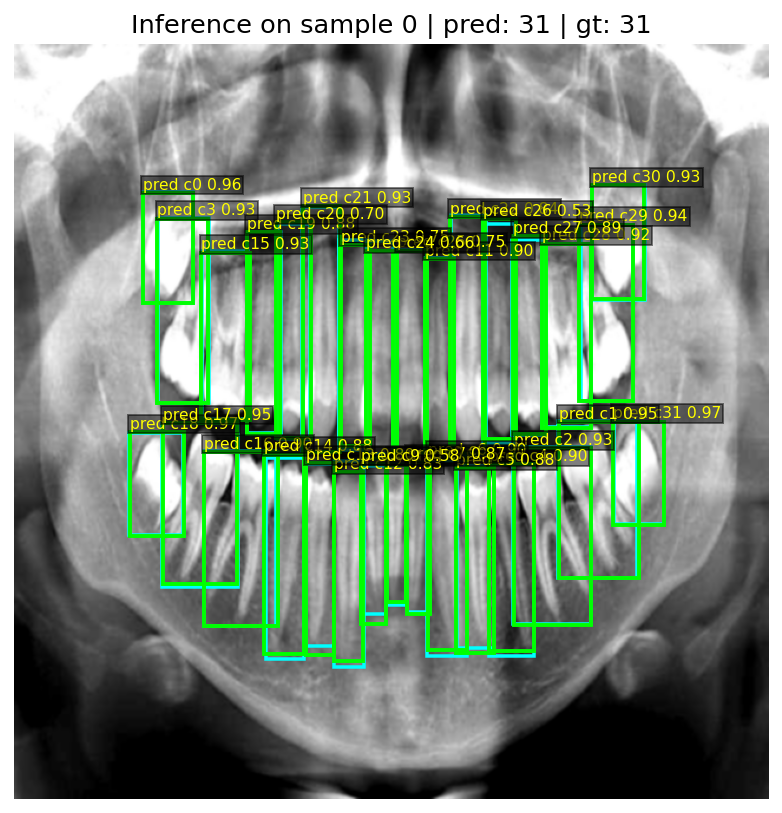

In [14]:
from io import BytesIO

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from IPython.display import Image, display

# Pick one sample from the tiny subset and run model inference.
sample_index = 0
image, target = datamodule.train_ds[sample_index]
image_batch = image.unsqueeze(0).to(model.device).float()

model.eval()
with torch.no_grad():
    raw_output = model(image_batch)
    preds = raw_output[0] if isinstance(raw_output, (tuple, list)) else raw_output
    nms_preds = non_max_suppression(
        preds,
        conf_thres=0.3,
        iou_thres=0.5,
        multi_label=False,
        max_det=32,
    )

det = nms_preds[0]
img = image.detach().cpu().float()
if img.ndim == 3 and img.shape[0] in (1, 3):
    img = img.permute(1, 2, 0)
img = img.numpy()

min_v = float(np.min(img))
max_v = float(np.max(img))
if max_v > min_v:
    img = (img - min_v) / (max_v - min_v)
else:
    img = np.zeros_like(img, dtype=np.float32)
img = np.clip(img, 0.0, 1.0)

fig, ax = plt.subplots(1, 1, figsize=(7, 7))
if img.ndim == 2:
    ax.imshow(img, cmap='gray')
else:
    ax.imshow(img)

# Draw ground-truth boxes in cyan.
gt_boxes = target['boxes'].detach().cpu().numpy()
for b in gt_boxes:
    x1, y1, x2, y2 = b.tolist()
    ax.add_patch(Rectangle((x1, y1), max(0.0, x2 - x1), max(0.0, y2 - y1), fill=False, linewidth=1.8, edgecolor='cyan'))

# Draw predicted boxes in lime.
num_pred = 0
if det is not None and len(det) > 0:
    det_cpu = det.detach().cpu().numpy()
    num_pred = len(det_cpu)
    for row in det_cpu:
        x1, y1, x2, y2, conf, cls = row.tolist()
        ax.add_patch(Rectangle((x1, y1), max(0.0, x2 - x1), max(0.0, y2 - y1), fill=False, linewidth=2.0, edgecolor='lime'))
        ax.text(
            x1,
            max(y1 - 3.0, 0.0),
            f'pred c{int(cls)} {conf:.2f}',
            color='yellow',
            fontsize=8,
            bbox={'facecolor': 'black', 'alpha': 0.5, 'pad': 1},
        )

ax.set_title(f'Inference on sample {sample_index} | pred: {num_pred} | gt: {len(gt_boxes)}')
ax.axis('off')

buffer = BytesIO()
fig.savefig(buffer, format='png', bbox_inches='tight', dpi=140)
buffer.seek(0)
display(Image(data=buffer.getvalue()))
plt.close(fig)

In [10]:
metrics = trainer.validate(model, datamodule=datamodule, verbose=False)[0]
final_map = float(metrics.get('val/map', 0.0))

print('Best checkpoint:', checkpoint_cb.best_model_path)
print('Final val/map (same tiny train subset):', final_map)

if final_map >= 0.90:
    print('OVERFIT CHECK PASSED: model can memorize the tiny subset.')
else:
    print('OVERFIT CHECK NOT YET PASSED: investigate data/labels/loss setup before full training.')

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Using fixed tiny subset of 16 samples for both train and val.


Best checkpoint: /work/output/checkpoints/yolov5-overfit-epoch=78-val_map=0.0000.ckpt
Final val/map (same tiny train subset): 0.9250909686088562
OVERFIT CHECK PASSED: model can memorize the tiny subset.


wandb: WARNING Artifact "model-bbqqfr61" already exists with the same content. No new version will be created.


## How to use this result

- If overfit passes, move to larger subsets and then full training.
- If it fails, inspect labels, box scaling, class indexing, and augmentations.
- Keep this notebook as a recurring regression test when changing data pipelines.